In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Setting logging to print only error messages from sklearn
import logging
logging.basicConfig()
logging.getLogger("SKLEARNEX").setLevel(logging.ERROR)

# Import warnings module
import warnings
warnings.filterwarnings("ignore") # Ignore warnings

# Data Preprocessing
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

# Machine Learning
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# Metrics
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, precision_recall_curve, auc

# Timer
import time
from timeit import default_timer as timer
from datetime import timedelta
from tqdm import tqdm

# **1. Load Data**

In [82]:
from google.colab import files
uploaded = files.upload()

Saving Dataset_E-Commerce Shipping_Classification.csv to Dataset_E-Commerce Shipping_Classification (1).csv


In [83]:
df = pd.read_csv("Dataset_E-Commerce Shipping_Classification.csv")
df

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10994,10995,A,Ship,4,1,252,5,medium,F,1,1538,1
10995,10996,B,Ship,4,1,232,5,medium,F,6,1247,0
10996,10997,C,Ship,5,4,242,5,low,F,4,1155,0
10997,10998,F,Ship,5,2,223,6,medium,M,2,1210,0


In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   10999 non-null  int64 
 1   Warehouse_block      10999 non-null  object
 2   Mode_of_Shipment     10999 non-null  object
 3   Customer_care_calls  10999 non-null  int64 
 4   Customer_rating      10999 non-null  int64 
 5   Cost_of_the_Product  10999 non-null  int64 
 6   Prior_purchases      10999 non-null  int64 
 7   Product_importance   10999 non-null  object
 8   Gender               10999 non-null  object
 9   Discount_offered     10999 non-null  int64 
 10  Weight_in_gms        10999 non-null  int64 
 11  Reached.on.Time_Y.N  10999 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.0+ MB


In [85]:
df.duplicated().sum()

np.int64(0)

In [86]:
df=df.drop("ID",axis=1 )
df=df.drop("Gender",axis=1 )

# **2. Data Partitioning**

In [87]:
# Train-test split
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.2, stratify=df["Reached.on.Time_Y.N"], random_state=99)

In this dataset, Reached.on.Time_Y.N is encoded as: 0 = Delivered On Time, 1 = Delivered Late.

In [88]:
# Reset index for both trainset and testset
train = train.reset_index(drop=True)
test = test.reset_index(drop=True)

In [89]:
train.shape, test.shape

((8799, 10), (2200, 10))

# **3. Exploratory Data Analysis**

**Data Shape and Data Type**

In [90]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8799 entries, 0 to 8798
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Warehouse_block      8799 non-null   object
 1   Mode_of_Shipment     8799 non-null   object
 2   Customer_care_calls  8799 non-null   int64 
 3   Customer_rating      8799 non-null   int64 
 4   Cost_of_the_Product  8799 non-null   int64 
 5   Prior_purchases      8799 non-null   int64 
 6   Product_importance   8799 non-null   object
 7   Discount_offered     8799 non-null   int64 
 8   Weight_in_gms        8799 non-null   int64 
 9   Reached.on.Time_Y.N  8799 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 687.6+ KB


In [91]:
train.head()

,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,B,Ship,2,2,271,4,medium,9,4066,0
1,D,Ship,4,2,249,3,low,6,5051,1
2,F,Ship,4,1,265,4,low,30,3896,1
3,D,Ship,3,2,145,2,medium,29,1690,1
4,A,Ship,2,1,211,3,low,6,1760,1


In [92]:
train['Reached.on.Time_Y.N'].value_counts()

,count
Reached.on.Time_Y.N,
1,5250
0,3549


In [93]:
cat_var = ["Warehouse_block", "Mode_of_Shipment", "Product_importance", "Reached.on.Time_Y.N"]

In [94]:
train[cat_var] = train[cat_var].astype("category")

In [95]:
test[cat_var] = test[cat_var].astype("category")

In [96]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8799 entries, 0 to 8798
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   Warehouse_block      8799 non-null   category
 1   Mode_of_Shipment     8799 non-null   category
 2   Customer_care_calls  8799 non-null   int64   
 3   Customer_rating      8799 non-null   int64   
 4   Cost_of_the_Product  8799 non-null   int64   
 5   Prior_purchases      8799 non-null   int64   
 6   Product_importance   8799 non-null   category
 7   Discount_offered     8799 non-null   int64   
 8   Weight_in_gms        8799 non-null   int64   
 9   Reached.on.Time_Y.N  8799 non-null   category
dtypes: category(4), int64(6)
memory usage: 447.5 KB


# **Data Cleaning**

**Handling Missing Values**

In [97]:
train.columns[train.isnull().any()]

Index([], dtype='object')

In [98]:
test.columns[train.isnull().any()]

Index([], dtype='object')

In [99]:
train.isnull().sum()

,0
Warehouse_block,0
Mode_of_Shipment,0
Customer_care_calls,0
Customer_rating,0
Cost_of_the_Product,0
Prior_purchases,0
Product_importance,0
Discount_offered,0
Weight_in_gms,0
Reached.on.Time_Y.N,0


In [100]:
test.isnull().sum()

,0
Warehouse_block,0
Mode_of_Shipment,0
Customer_care_calls,0
Customer_rating,0
Cost_of_the_Product,0
Prior_purchases,0
Product_importance,0
Discount_offered,0
Weight_in_gms,0
Reached.on.Time_Y.N,0


No missing value was found.

# **3.1. Univariate Analysis**

In [101]:
#Categorical variables - value_counts
categorical_columns = ["Warehouse_block", "Mode_of_Shipment", "Product_importance", "Reached.on.Time_Y.N"]

for col in categorical_columns:
    print(f"\n{col.upper()} value counts:")
    display(train[col].value_counts().to_frame('count'))


WAREHOUSE_BLOCK value counts:


,count
Warehouse_block,
F,2913
A,1489
B,1476
C,1470
D,1451



MODE_OF_SHIPMENT value counts:


,count
Mode_of_Shipment,
Ship,5979
Flight,1410
Road,1410



PRODUCT_IMPORTANCE value counts:


,count
Product_importance,
low,4243
medium,3797
high,759



REACHED.ON.TIME_Y.N value counts:


,count
Reached.on.Time_Y.N,
1,5250
0,3549


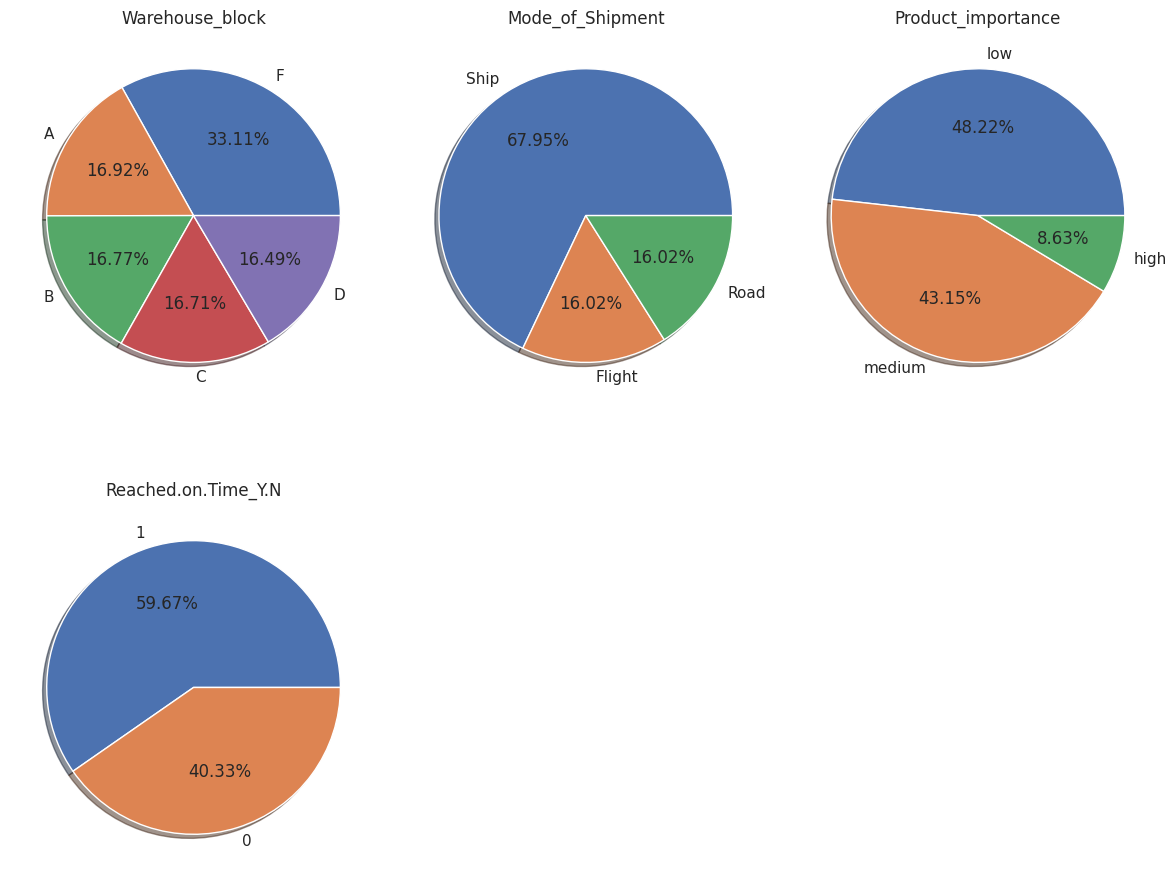

In [102]:
# Categorical variables - pie chart
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 10))
axes = axes.flatten()

for i, var in enumerate(cat_var):
    if i >= 5:
        break
    x = train[var].value_counts()
    y = x.index

    axes[i].pie(x, labels=y, shadow=True, autopct="%.2f%%")
    axes[i].set_title(var)

for j in range(len(cat_var), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

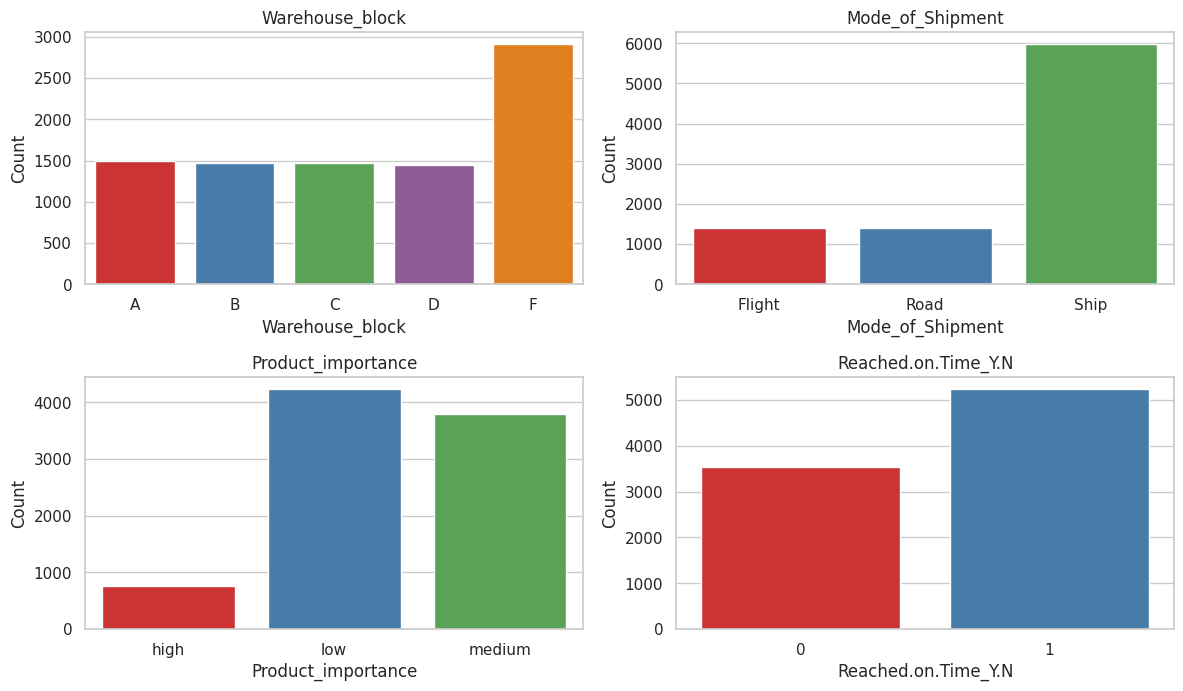

In [103]:
# Countplot categorical variables
categorical_columns = ["Warehouse_block", "Mode_of_Shipment", "Product_importance", "Reached.on.Time_Y.N"]

fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_columns):
    sns.countplot(x=col, data=train, palette='Set1', hue=col, legend=False, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis='x')

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [104]:
num_columns = ["Customer_care_calls",	"Customer_rating",	"Cost_of_the_Product", "Prior_purchases", "Discount_offered", "Weight_in_gms"]

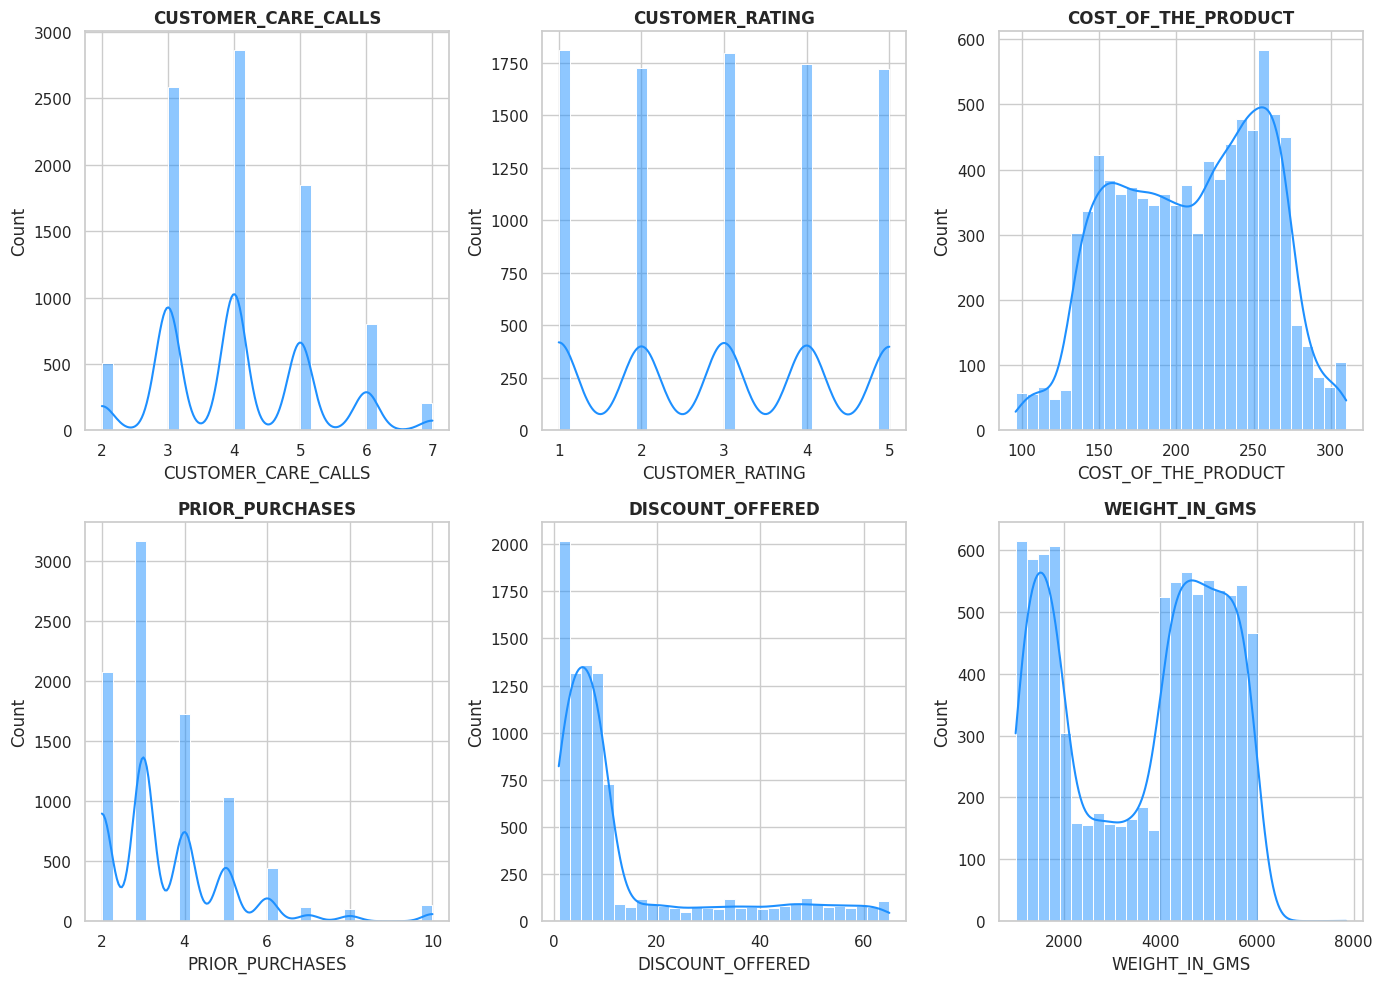

In [105]:
#Numerical variables - histogram
fig, axes = plt.subplots(2, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(num_columns):

    sns.histplot(data=train, x=col, color='dodgerblue', kde=True, bins=30, ax=axes[i])
    axes[i].set_title(col.upper(), fontweight='bold')
    axes[i].set_ylabel('Count')
    axes[i].set_xlabel(col.upper())

plt.tight_layout()
plt.show()

# **3.2. Bivariate Analysis**

<Axes: xlabel='Mode_of_Shipment', ylabel='count'>

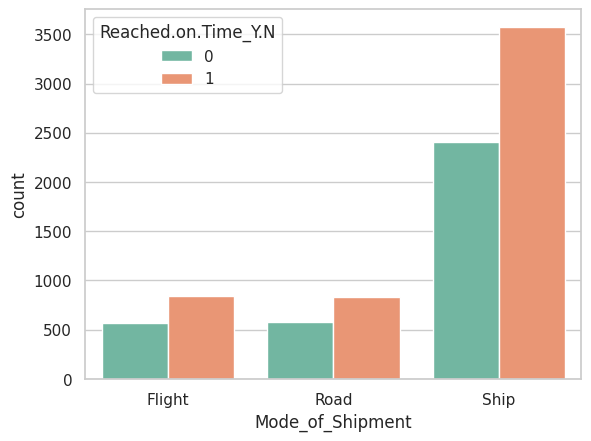

In [106]:
sns.countplot(train, x="Mode_of_Shipment", hue="Reached.on.Time_Y.N", palette='Set2')

<Axes: xlabel='Product_importance', ylabel='count'>

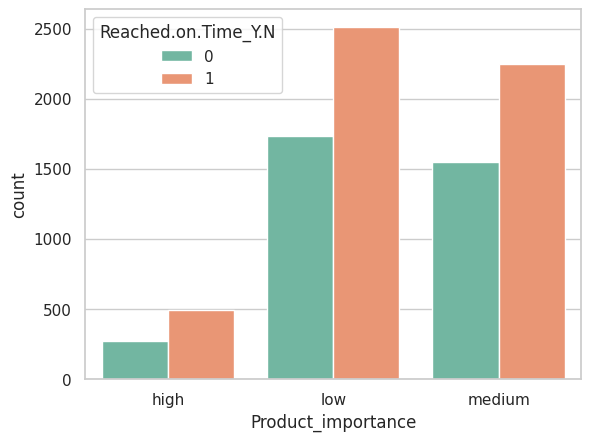

In [107]:
sns.countplot(train, x="Product_importance", hue="Reached.on.Time_Y.N", palette='Set2')

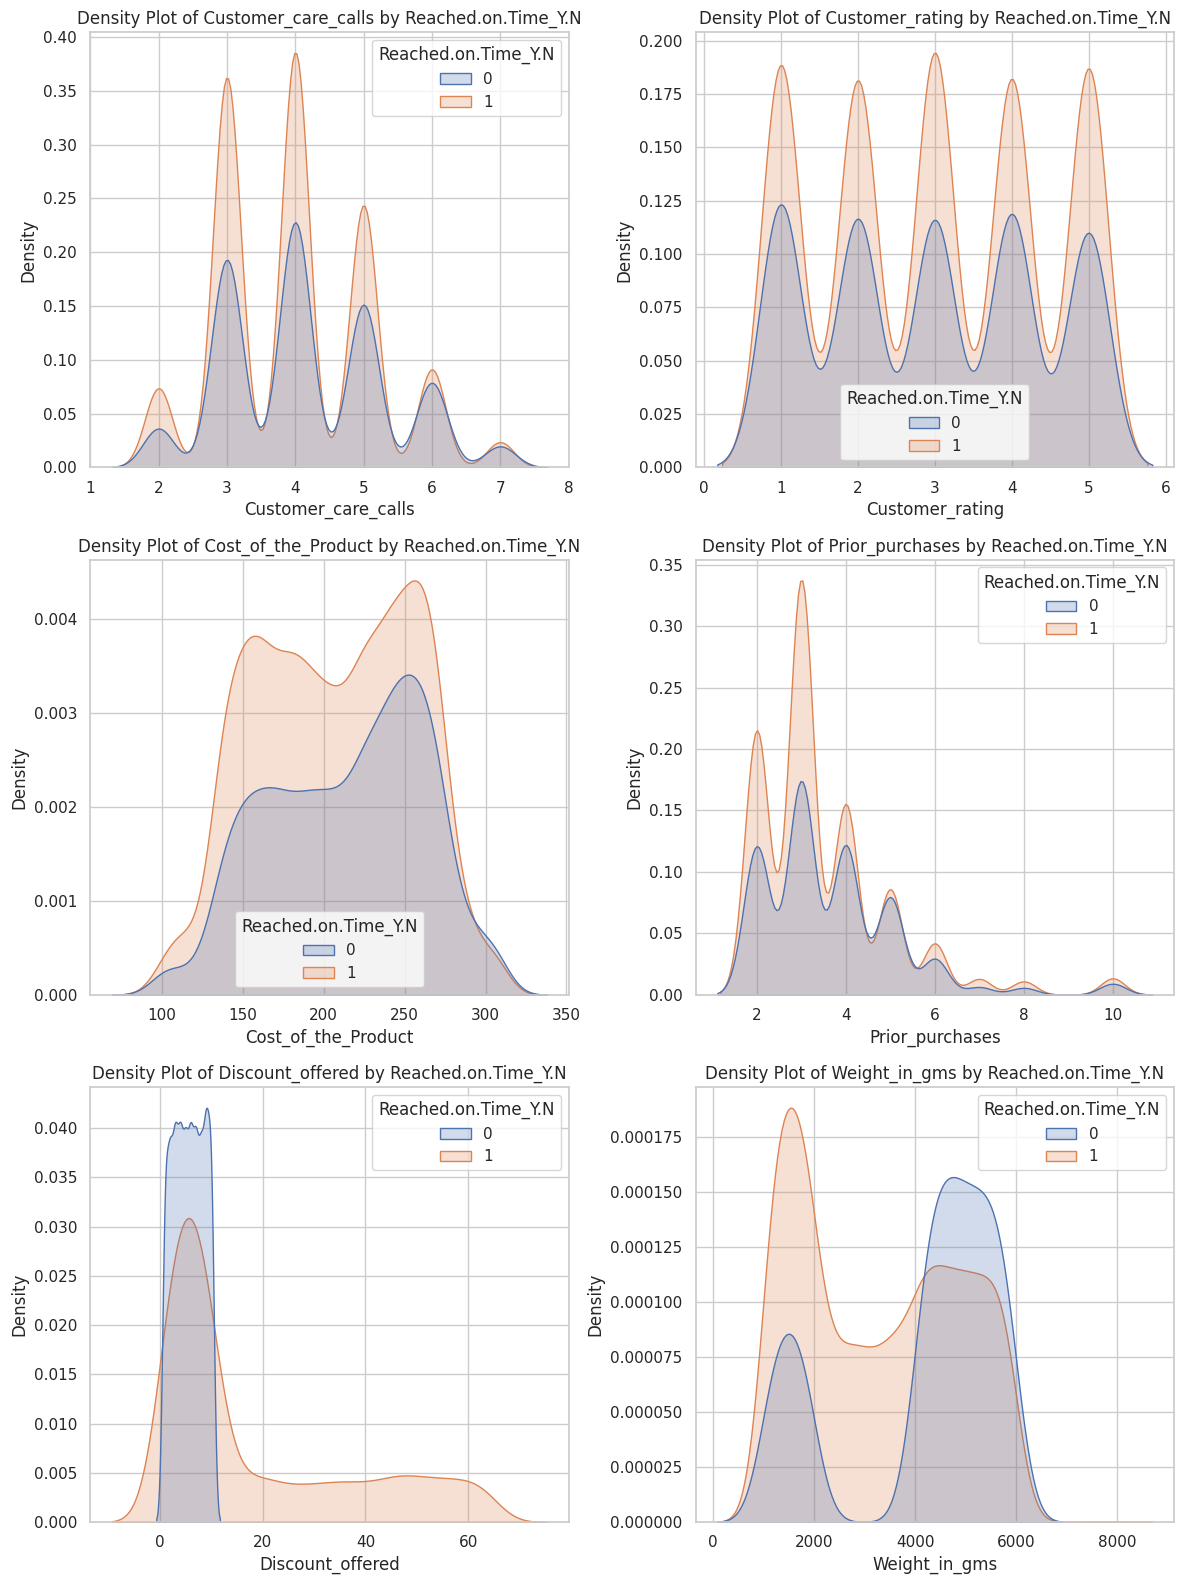

In [108]:
plt.figure(figsize=(12, 16))

for i, col in enumerate(num_columns, 1):
    plt.subplot(3, 2, i)
    sns.kdeplot(data=train, x=col, hue='Reached.on.Time_Y.N', shade=True)
    plt.title(f"Density Plot of {col} by Reached.on.Time_Y.N", fontsize=12)

plt.tight_layout()
plt.show()

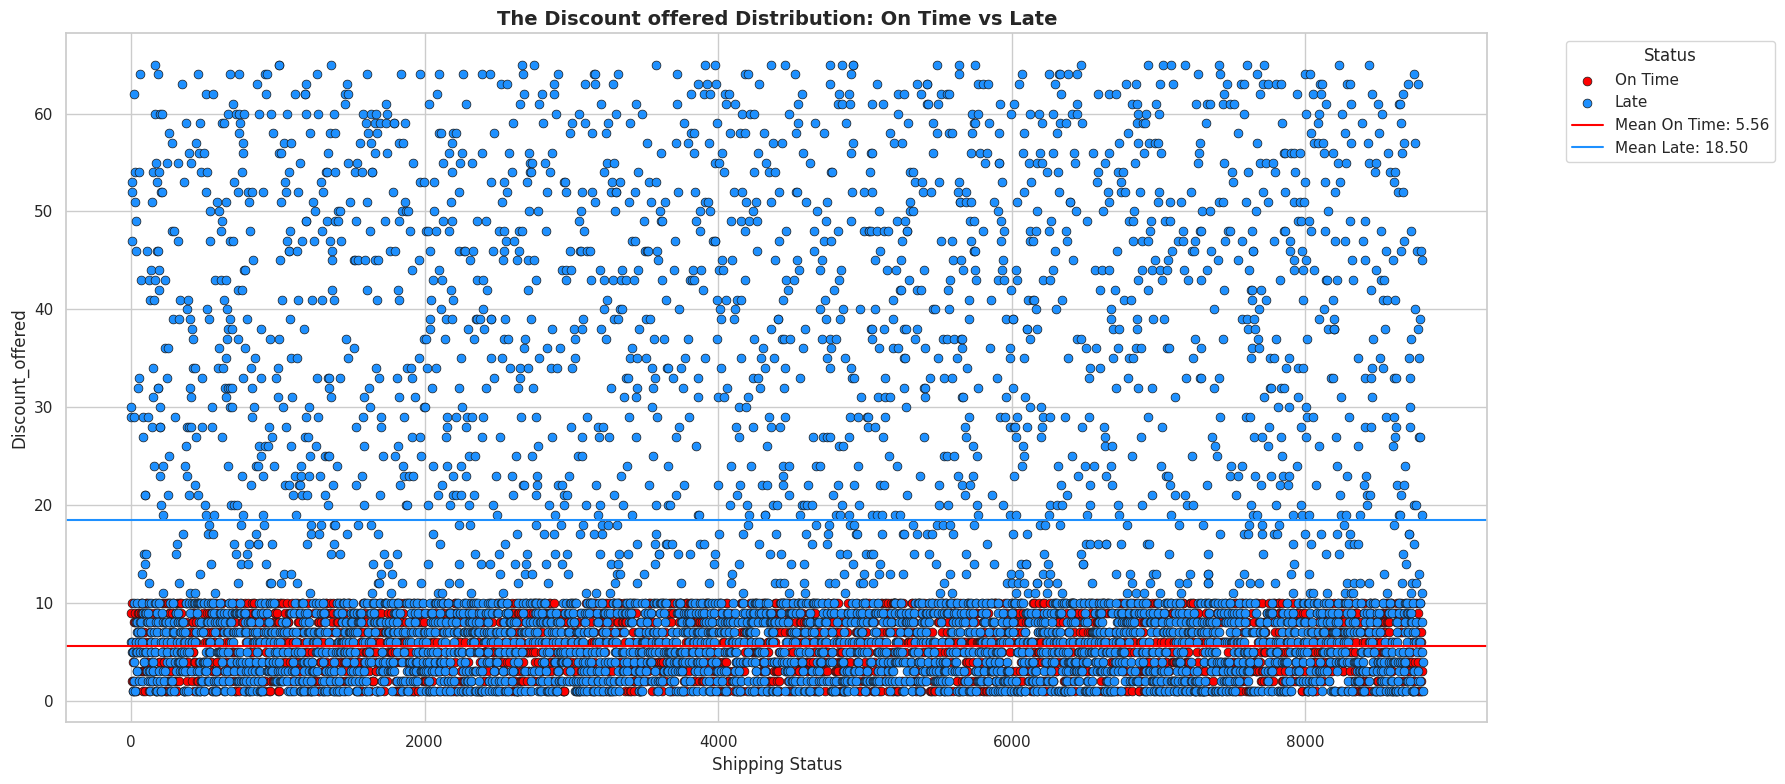

In [109]:
# Set the Seaborn style
sns.set(style="whitegrid")

# Separate the data
On_Time = train[train['Reached.on.Time_Y.N'] == 0]
Late = train[train['Reached.on.Time_Y.N'] == 1]

# Calculate mean amounts
mean_On_Time = On_Time["Discount_offered"].mean()
mean_Late = Late["Discount_offered"].mean()

# Create a figure and axis
fig, ax = plt.subplots(figsize=(18, 8))

# Plot the data
sns.scatterplot(x=On_Time.index, y=On_Time["Discount_offered"], color="red",
                s=40, edgecolor="k", label="On Time", ax=ax)
sns.scatterplot(x=Late.index, y=Late["Discount_offered"], color="DodgerBlue",
                s=40, edgecolor="k", label="Late", ax=ax)

# Add dashed lines for mean amounts
ax.axhline(y=mean_On_Time, color="red", label=f"Mean On Time: {mean_On_Time:.2f}")
ax.axhline(y=mean_Late, color="DodgerBlue", label=f"Mean Late: {mean_Late:.2f}")

# Add labels and title
ax.set_xlabel("Shipping Status", fontsize=12)
ax.set_ylabel("Discount_offered", fontsize=12)
ax.set_title("The Discount offered Distribution: On Time vs Late", fontsize=14, fontweight='bold')

# Add legend
ax.legend(title="Status", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Display the plot
plt.show()

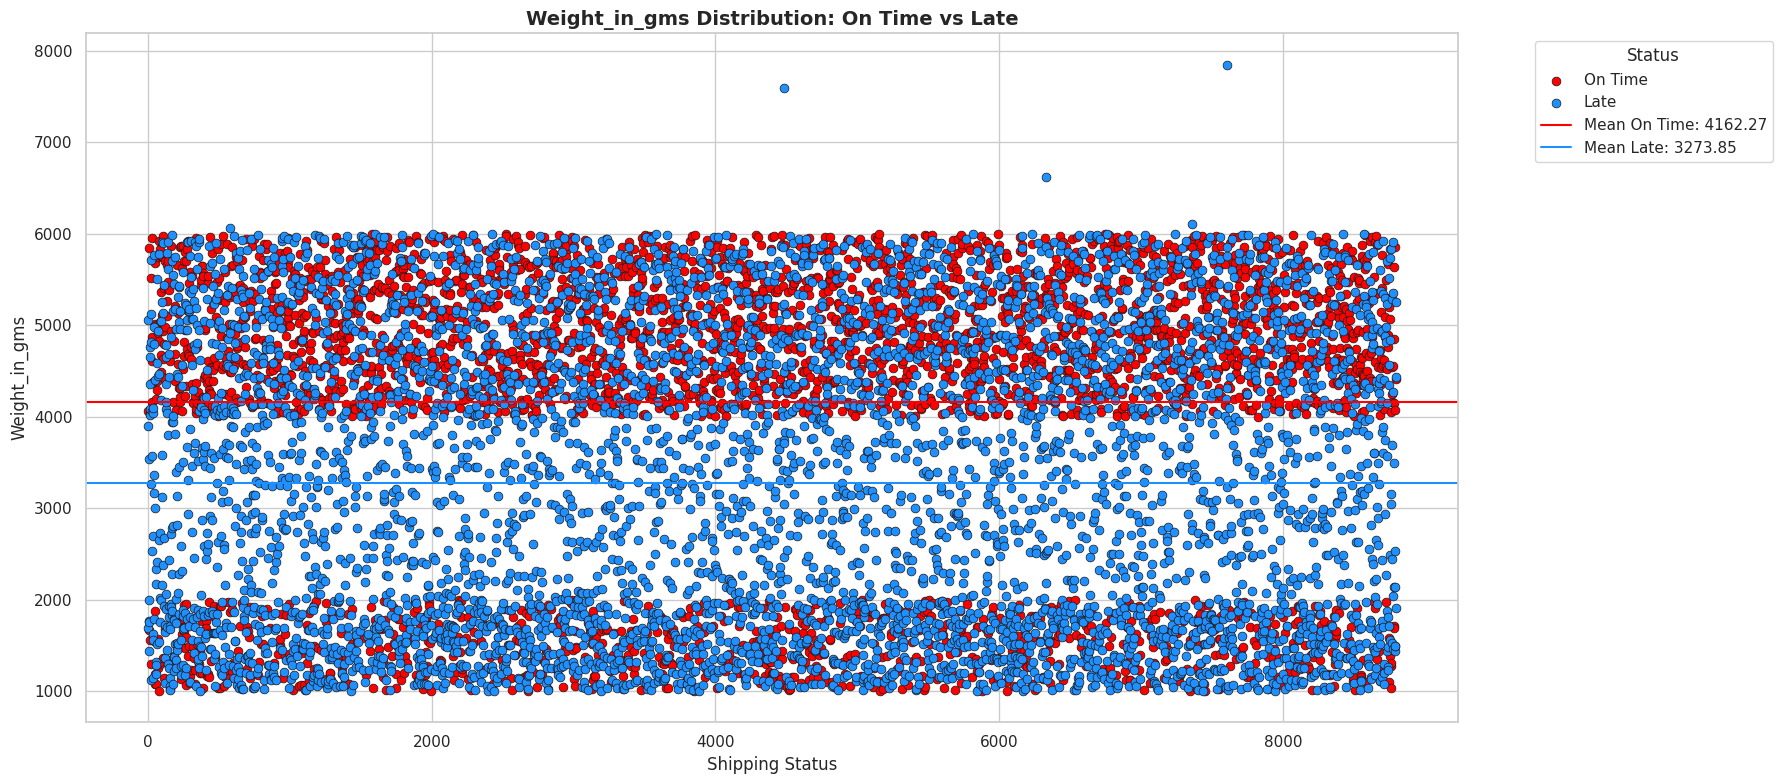

In [110]:
# Set the Seaborn style
sns.set(style="whitegrid")

# Separate the data
On_Time = train[train['Reached.on.Time_Y.N'] == 0]
Late = train[train['Reached.on.Time_Y.N'] == 1]

# Calculate mean amounts
mean_On_Time = On_Time["Weight_in_gms"].mean()
mean_Late = Late["Weight_in_gms"].mean()

# Create a figure and axis
fig, ax = plt.subplots(figsize=(18, 8))

# Plot the data
sns.scatterplot(x=On_Time.index, y=On_Time["Weight_in_gms"], color="red",
                s=40, edgecolor="k", label="On Time", ax=ax)
sns.scatterplot(x=Late.index, y=Late["Weight_in_gms"], color="DodgerBlue",
                s=40, edgecolor="k", label="Late", ax=ax)

# Add dashed lines for mean amounts
ax.axhline(y=mean_On_Time, color="red", label=f"Mean On Time: {mean_On_Time:.2f}")
ax.axhline(y=mean_Late, color="DodgerBlue", label=f"Mean Late: {mean_Late:.2f}")

# Add labels and title
ax.set_xlabel("Shipping Status", fontsize=12)
ax.set_ylabel("Weight_in_gms", fontsize=12)
ax.set_title("Weight_in_gms Distribution: On Time vs Late", fontsize=14, fontweight='bold')

# Add legend
ax.legend(title="Status", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Display the plot
plt.show()

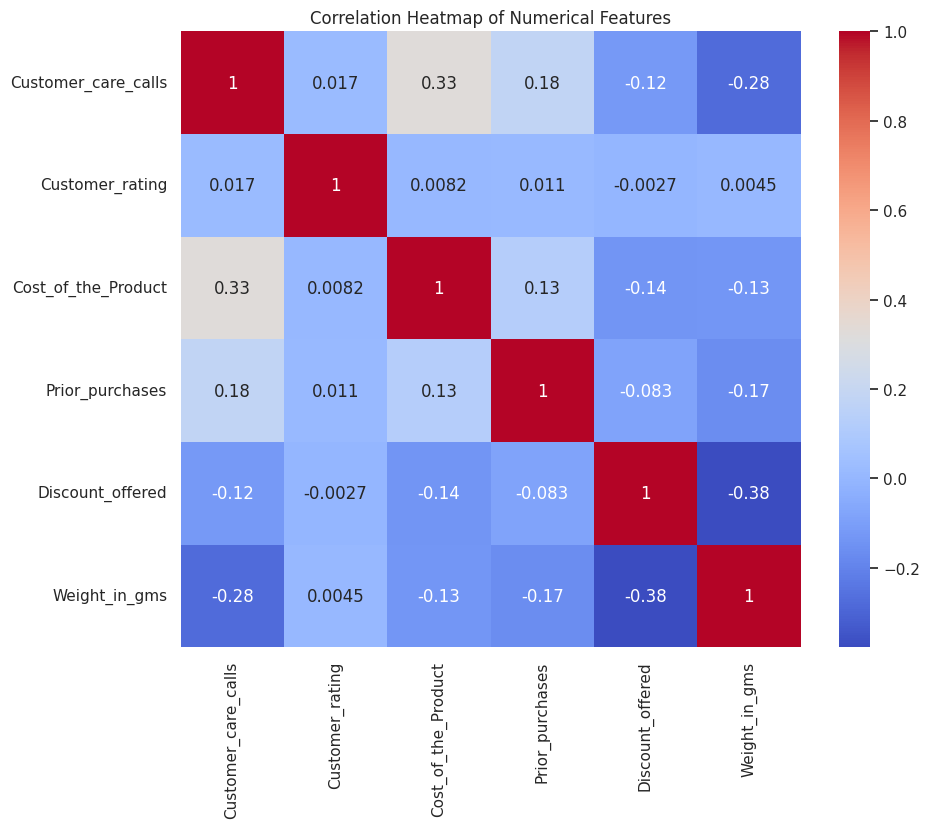

In [111]:
#Correlation Heatmap for numeric varibales before transforming
plt.figure(figsize=(10,8))
sns.heatmap(train[num_columns].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

# **Checking outliers**

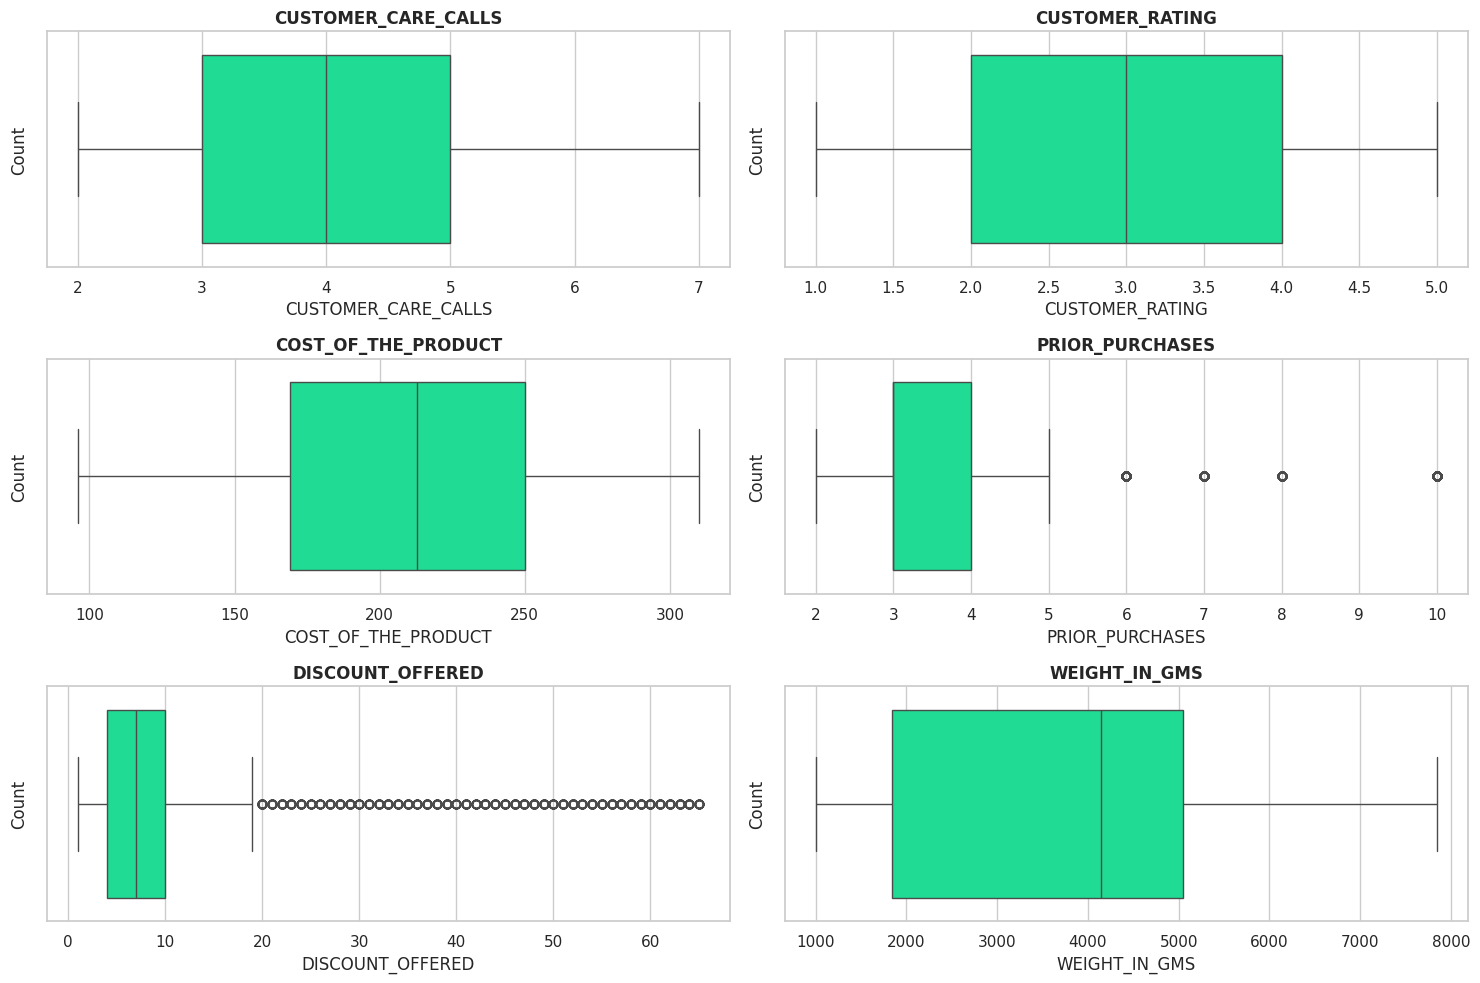

In [112]:
#Numerical variables - boxplot
fig, axes = plt.subplots(3, 2, figsize=(15,10))
axes = axes.flatten()

for i, col in enumerate(num_columns):
    sns.boxplot(data=train, x=col, color='mediumspringgreen', ax=axes[i])
    axes[i].set_title(col.upper(), fontweight='bold')
    axes[i].set_ylabel('Count')
    axes[i].set_xlabel(col.upper())

plt.tight_layout()
plt.show()

In [113]:
for col in num_columns:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1

    outliers = train[(train[col] < Q1 - 1.5*IQR) | (train[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} outliers")

Customer_care_calls: 0 outliers
Customer_rating: 0 outliers
Cost_of_the_Product: 0 outliers
Prior_purchases: 797 outliers
Discount_offered: 1737 outliers
Weight_in_gms: 0 outliers


Although the numerical variables Prior_purchases (797 outliers) and Discount_offered (1737 outliers) contain a high number of extreme values, these data points represent real customer behavior and business strategies rather than data entry errors.

In the E-commerce and Logistics domain, an exceptionally high number of prior purchases indicates loyal customers or wholesale buyers. Similarly, extreme discount values are valid signals resulting from major promotional campaigns or flash sales.

Therefore, these outliers were retained and not removed or modified, as eliminating them would strip away crucial signals regarding high value customers and the direct impact of heavy discounting on customer behavior.

# **4. Data Transformation**

In [114]:
train.head()

,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,B,Ship,2,2,271,4,medium,9,4066,0
1,D,Ship,4,2,249,3,low,6,5051,1
2,F,Ship,4,1,265,4,low,30,3896,1
3,D,Ship,3,2,145,2,medium,29,1690,1
4,A,Ship,2,1,211,3,low,6,1760,1


In [115]:
test.head()

,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,B,Road,4,3,189,3,medium,4,4410,0
1,A,Flight,7,5,302,4,low,3,1597,1
2,B,Ship,4,1,272,2,medium,5,5252,0
3,F,Flight,3,4,204,3,medium,27,2772,1
4,B,Ship,4,4,193,3,medium,8,4715,1


# **4.1. Category Encoding**

In [116]:
from sklearn.preprocessing import OneHotEncoder
one_hot_encoder = OneHotEncoder( sparse_output=False)

# categorical columns to transform
cat_cols = ["Warehouse_block", "Mode_of_Shipment", "Product_importance"]

# fit an encoder and transform the trainset
cat_vals = train[cat_cols]
cat_vals

,Warehouse_block,Mode_of_Shipment,Product_importance
0,B,Ship,medium
1,D,Ship,low
2,F,Ship,low
3,D,Ship,medium
4,A,Ship,low
...,...,...,...
8794,C,Ship,low
8795,F,Ship,low
8796,F,Ship,medium
8797,F,Ship,low


In [117]:
# Fit and transform the categorical values
transformed = one_hot_encoder.fit_transform(cat_vals)
transformed

array([[0., 1., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 1., 0., 0.]])

In [118]:
# the names of the new columns
new_col_names = one_hot_encoder.get_feature_names_out(cat_cols)
new_col_names

array(['Warehouse_block_A', 'Warehouse_block_B', 'Warehouse_block_C',
       'Warehouse_block_D', 'Warehouse_block_F',
       'Mode_of_Shipment_Flight', 'Mode_of_Shipment_Road',
       'Mode_of_Shipment_Ship', 'Product_importance_high',
       'Product_importance_low', 'Product_importance_medium'],
      dtype=object)

In [119]:
# put the transformed data as columns in the trainset dataframe
for i, new_col_name in enumerate(new_col_names):
    train[new_col_name] = transformed[:,i]

# check if the dummies are produced correctly in the trainset
train.head()

,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,...,Warehouse_block_B,Warehouse_block_C,Warehouse_block_D,Warehouse_block_F,Mode_of_Shipment_Flight,Mode_of_Shipment_Road,Mode_of_Shipment_Ship,Product_importance_high,Product_importance_low,Product_importance_medium
0,B,Ship,2,2,271,4,medium,9,4066,0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,D,Ship,4,2,249,3,low,6,5051,1,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,F,Ship,4,1,265,4,low,30,3896,1,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
3,D,Ship,3,2,145,2,medium,29,1690,1,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,A,Ship,2,1,211,3,low,6,1760,1,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [120]:
# delete the original categorical columns
train = train.drop(cat_cols, axis=1)

In [121]:
train.head()

,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,Warehouse_block_A,Warehouse_block_B,Warehouse_block_C,Warehouse_block_D,Warehouse_block_F,Mode_of_Shipment_Flight,Mode_of_Shipment_Road,Mode_of_Shipment_Ship,Product_importance_high,Product_importance_low,Product_importance_medium
0,2,2,271,4,9,4066,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,4,2,249,3,6,5051,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,4,1,265,4,30,3896,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
3,3,2,145,2,29,1690,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,2,1,211,3,6,1760,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [122]:
# transform the testing set using the encoder fitted on test
cat_vals = test[cat_cols]
transformed = one_hot_encoder.transform(cat_vals)

# put the transformed data as columns in the testset dataframe
for i, new_col_name in enumerate(new_col_names):
    test[new_col_name] = transformed[:,i]

# check if the dummies are produced correctly in the testset
test.head()

,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,...,Warehouse_block_B,Warehouse_block_C,Warehouse_block_D,Warehouse_block_F,Mode_of_Shipment_Flight,Mode_of_Shipment_Road,Mode_of_Shipment_Ship,Product_importance_high,Product_importance_low,Product_importance_medium
0,B,Road,4,3,189,3,medium,4,4410,0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,A,Flight,7,5,302,4,low,3,1597,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,B,Ship,4,1,272,2,medium,5,5252,0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,F,Flight,3,4,204,3,medium,27,2772,1,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
4,B,Ship,4,4,193,3,medium,8,4715,1,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


In [123]:
columns_to_drop_from_test = [ "Warehouse_block", "Mode_of_Shipment", "Product_importance"]
test = test.drop(columns=columns_to_drop_from_test, errors='ignore')
test.head()

,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,Warehouse_block_A,Warehouse_block_B,Warehouse_block_C,Warehouse_block_D,Warehouse_block_F,Mode_of_Shipment_Flight,Mode_of_Shipment_Road,Mode_of_Shipment_Ship,Product_importance_high,Product_importance_low,Product_importance_medium
0,4,3,189,3,4,4410,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,7,5,302,4,3,1597,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,4,1,272,2,5,5252,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,3,4,204,3,27,2772,1,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
4,4,4,193,3,8,4715,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


In [124]:
test.shape

(2200, 18)

In [125]:
# separate the target and predictors
ytrain = train["Reached.on.Time_Y.N"].copy()
Xtrain = train.drop("Reached.on.Time_Y.N", axis=1)
ytest = test["Reached.on.Time_Y.N"].copy()
Xtest = test.drop("Reached.on.Time_Y.N", axis=1)

In [126]:
Xtrain.shape, ytrain.shape, Xtest.shape, ytest.shape

((8799, 17), (8799,), (2200, 17), (2200,))

In [127]:
Xtrain.head()

,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Warehouse_block_A,Warehouse_block_B,Warehouse_block_C,Warehouse_block_D,Warehouse_block_F,Mode_of_Shipment_Flight,Mode_of_Shipment_Road,Mode_of_Shipment_Ship,Product_importance_high,Product_importance_low,Product_importance_medium
0,2,2,271,4,9,4066,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,4,2,249,3,6,5051,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,4,1,265,4,30,3896,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
3,3,2,145,2,29,1690,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,2,1,211,3,6,1760,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


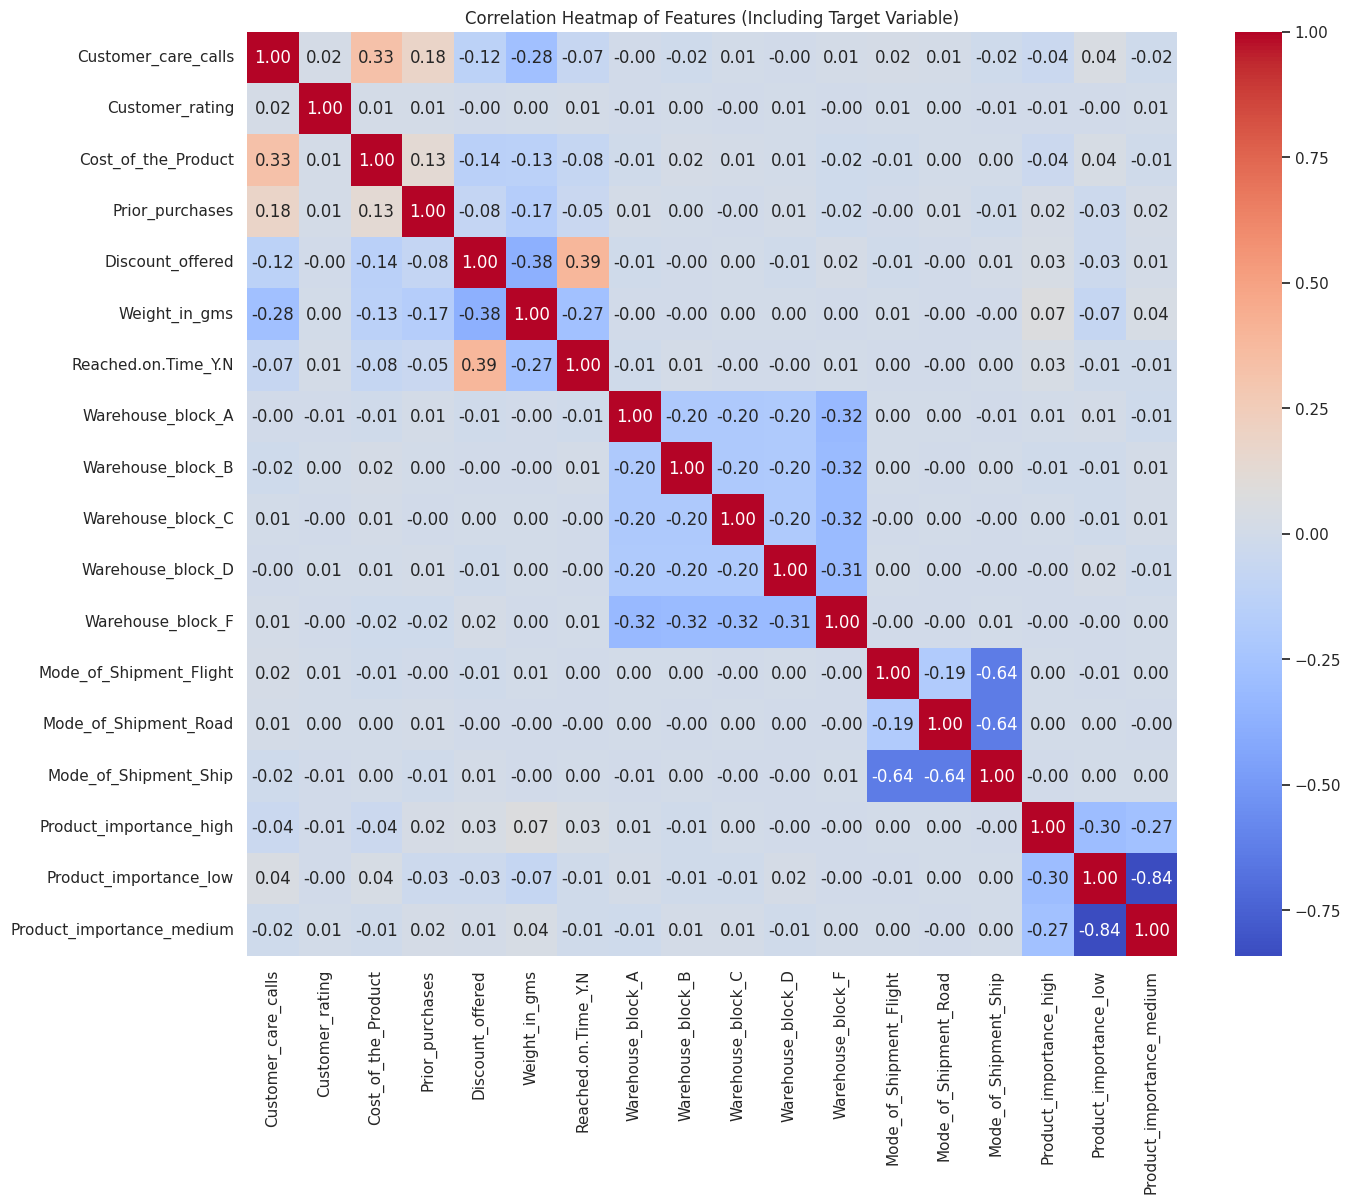

In [128]:
# Create a copy to avoid modifying the original 'train' DataFrame's dtype permanently for other operations
train_for_corr = train.copy()
# Convert the target variable to numeric (int) to include it in the correlation calculation
train_for_corr['Reached.on.Time_Y.N'] = train_for_corr['Reached.on.Time_Y.N'].astype(int)

plt.figure(figsize=(15, 12))
# Use the new DataFrame for correlation. Remove numeric_only=True to ensure all processed columns are included.
sns.heatmap(train_for_corr.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Features (Including Target Variable)')
plt.show()

# **Scaling**

In [129]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit on training data and transform both training and test sets
X_train_scaled = scaler.fit_transform(Xtrain)
X_test_scaled = scaler.transform(Xtest)

In [130]:
Xtrain = X_train_scaled
Xtest = X_test_scaled

In [131]:
Xtrain, Xtest

(array([[-1.79787752, -0.69426532,  1.27523857, ..., -0.30725069,
         -0.96503854,  1.14776122],
        [-0.04492453, -0.69426532,  0.81620163, ..., -0.30725069,
          1.03622804, -0.87126136],
        [-0.04492453, -1.40155264,  1.15004668, ..., -0.30725069,
          1.03622804, -0.87126136],
        ...,
        [-0.04492453,  0.72030931, -0.01841099, ..., -0.30725069,
         -0.96503854,  1.14776122],
        [-0.04492453, -1.40155264,  0.81620163, ..., -0.30725069,
          1.03622804, -0.87126136],
        [-0.92140102, -0.69426532, -0.08100694, ...,  3.25467132,
         -0.96503854, -0.87126136]]),
 array([[-4.49245256e-02,  1.30219963e-02, -4.35717303e-01, ...,
         -3.07250688e-01, -9.65038541e-01,  1.14776122e+00],
        [ 2.58450497e+00,  1.42759663e+00,  1.92206336e+00, ...,
         -3.07250688e-01,  1.03622804e+00, -8.71261362e-01],
        [-4.49245256e-02, -1.40155264e+00,  1.29610389e+00, ...,
         -3.07250688e-01, -9.65038541e-01,  1.14776122e+

In [132]:
ytrain, ytest

(0       0
 1       1
 2       1
 3       1
 4       1
        ..
 8794    1
 8795    1
 8796    0
 8797    1
 8798    1
 Name: Reached.on.Time_Y.N, Length: 8799, dtype: category
 Categories (2, int64): [0, 1],
 0       0
 1       1
 2       0
 3       1
 4       1
        ..
 2195    0
 2196    1
 2197    1
 2198    1
 2199    1
 Name: Reached.on.Time_Y.N, Length: 2200, dtype: category
 Categories (2, int64): [0, 1])

# **5. Model Development**

In [133]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, auc, accuracy_score
from sklearn.model_selection import cross_val_score

In [134]:
def evaluate_model(model, ytest, Xtest):
    yhat = model.predict(Xtest)
    print(classification_report(ytest, yhat, zero_division=0))

# Displays cross-validation results with a given grid_search object
def print_cv_results(grid_search, col_width=100, max_rows=10):
    results = pd.DataFrame(grid_search.cv_results_
                             )[['params', 'mean_train_score', 'mean_test_score']]
    # Calculating the difference between mean_train_score and mean_test_score as a percentage
    results["diff, %"] = 100*(results["mean_train_score"]-results["mean_test_score"]
                                                         )/results["mean_train_score"]
    # Setting display options for pandas DataFrame
    pd.set_option('display.max_colwidth', col_width)
    pd.set_option('display.min_rows', max_rows)
    pd.set_option('display.max_rows', max_rows)
    display(results.sort_values('mean_test_score', ascending=False))

# **KNN**

In [135]:
from sklearn.neighbors import KNeighborsClassifier

In [136]:
param_grid = {'n_neighbors': [3, 5, 7, 9, 11, 15]}
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=10, scoring='f1_macro')
grid.fit(Xtrain, ytrain)
print("Best params:", grid.best_params_)

Best params: {'n_neighbors': 11}


In [137]:
knn = KNeighborsClassifier(n_neighbors=11)
knn_fscore = cross_val_score(knn, X_train_scaled, ytrain, scoring='f1_macro', cv=10)

In [138]:
knn_fscore

array([0.6253962 , 0.64148682, 0.64485856, 0.62721657, 0.62970561,
       0.62253092, 0.641867  , 0.63896297, 0.62613939, 0.64392361])

In [139]:
knn_fscore.mean()

np.float64(0.6342087639213433)

In [140]:
from sklearn.metrics import classification_report

# Predict on training set
knn.fit(Xtrain, ytrain)
y_pred_train_knn = knn.predict(Xtrain)

print(classification_report(ytrain, y_pred_train_knn, digits=4))

              precision    recall  f1-score   support

           0     0.6417    0.7332    0.6844      3549
           1     0.8004    0.7232    0.7599      5250

    accuracy                         0.7272      8799
   macro avg     0.7210    0.7282    0.7221      8799
weighted avg     0.7364    0.7272    0.7294      8799



# **SVM**

In [141]:
from sklearn.svm import SVC

In [142]:
svc = SVC()
svc_fscore = cross_val_score(svc, X_train_scaled, ytrain, scoring='f1_macro', cv=10)

In [143]:
svc_fscore

array([0.63081447, 0.64920092, 0.64264837, 0.65485774, 0.65493278,
       0.66195838, 0.65968894, 0.6325555 , 0.64997107, 0.63134413])

In [144]:
svc_fscore.mean()

np.float64(0.6467972302416674)

In [145]:
from sklearn.metrics import classification_report

# Predict on training set
svc.fit(Xtrain, ytrain)
y_pred_train_svc = svc.predict(Xtrain)

print(classification_report(ytrain, y_pred_train_svc, digits=4))

              precision    recall  f1-score   support

           0     0.5921    0.8253    0.6895      3549
           1     0.8390    0.6156    0.7102      5250

    accuracy                         0.7002      8799
   macro avg     0.7156    0.7205    0.6998      8799
weighted avg     0.7394    0.7002    0.7018      8799



# **Logistic Regression**

In [146]:
from sklearn.linear_model import LogisticRegression

In [147]:
lr = LogisticRegression()
lr_fscore = cross_val_score(lr, Xtrain, ytrain, scoring='f1_macro', cv=10)

In [148]:
lr_fscore

array([0.60426327, 0.63513427, 0.63644624, 0.62664604, 0.62986626,
       0.60238067, 0.65515598, 0.59372114, 0.6119868 , 0.62661498])

In [149]:
lr_fscore.mean()

np.float64(0.6222215662568154)

In [150]:
from sklearn.metrics import classification_report

# Predict on training set
lr.fit(Xtrain, ytrain)
y_pred_train_lr = lr.predict(Xtrain)

print(classification_report(ytrain, y_pred_train_lr, digits=4))

              precision    recall  f1-score   support

           0     0.5485    0.5734    0.5607      3549
           1     0.7025    0.6810    0.6916      5250

    accuracy                         0.6376      8799
   macro avg     0.6255    0.6272    0.6261      8799
weighted avg     0.6404    0.6376    0.6388      8799



# **Deep Learning (ANN)**


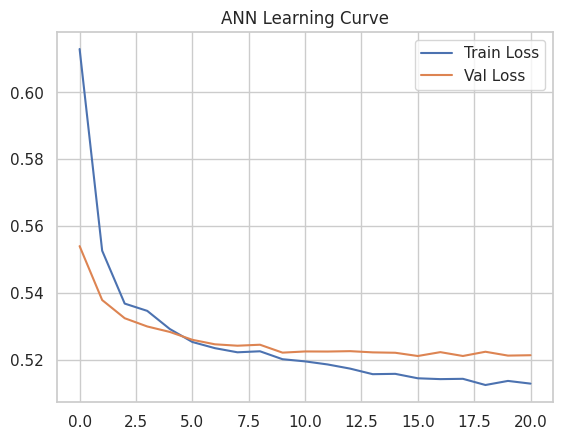

In [151]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

model = Sequential([
    Dense(64, activation='relu', input_shape=(Xtrain.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer=Adam(0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Convert ytrain to a numerical format compatible with TensorFlow/Keras
ytrain_numeric = ytrain.astype(int)

history = model.fit(Xtrain, ytrain_numeric,
                    epochs=30,
                    batch_size=32,
                    validation_split=0.2,
                    callbacks=[early_stop],
                    verbose=0)

# Vẽ learning curve
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('ANN Learning Curve')
plt.show()

# **Model Comparison**

ANN achieved the best performance on the training set. As a result, this is the final model.

In [152]:
# ============================
# FINAL COMPARISON: KNN, SVM, Logistic Regression, ANN
# ============================

from sklearn.metrics import accuracy_score, f1_score, recall_score, classification_report
import pandas as pd
import numpy as np

# --- UPDATE THESE NAMES TO MATCH YOUR ACTUAL TRAINED MODELS ---
models = {
    "KNN": knn,                    # your trained KNN
    "SVM": svc,                    # your trained SVM
    "Logistic Regression": lr, # your trained Logistic Regression
    "ANN (Neural Network)": model  # your Keras/TensorFlow model
}

results = []
print("Evaluating 4 models on Train & Test sets...\n")
print("="*85)

for name, mdl in models.items():
    print(f"Evaluating {name}...", end="")

    # Handle Keras ANN vs scikit-learn models
    if 'keras' in str(type(mdl)) or 'tensorflow' in str(type(mdl)):
        pred_train = (mdl.predict(Xtrain, verbose=0) > 0.5).astype(int).flatten()
        pred_test  = (mdl.predict(Xtest,  verbose=0) > 0.5).astype(int).flatten()
    else:
        pred_train = mdl.predict(Xtrain)
        pred_test  = mdl.predict(Xtest)

    # Ensure labels are numpy/array
    y_train = ytrain.values if hasattr(ytrain, 'values') else ytrain
    y_test  = ytest.values if hasattr(ytest, 'values') else ytest

    # Metrics
    train_acc = accuracy_score(y_train, pred_train)
    test_acc  = accuracy_score(y_test, pred_test)
    f1_macro  = f1_score(y_test, pred_test, average='macro')
    f1_OT    = f1_score(y_test, pred_test, pos_label=0)        # F1 for "On Time" (class 0)
    recall_OT = recall_score(y_test, pred_test, pos_label=0)   # Recall for On Time deliveries

    results.append({
        'Model': name,
        'Train Accuracy': round(train_acc, 4),
        'Test Accuracy': round(test_acc, 4),
        'F1-macro': round(f1_macro, 4),
        'F1-OT': round(f1_OT, 4),
        'Recall-OT': round(recall_OT, 4),
        'Overfitting Risk': 'High' if (train_acc - test_acc > 0.08) else 'Low'
    })
    print(" Done")

# Create and display results table
df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by='F1-OT', ascending=False).reset_index(drop=True)

print("\n" + "="*85)
print("MODEL COMPARISON (Sorted by F1-score of 'OT' class)")
print("="*85)
print(df_results.to_string(index=False))

# === BEST MODEL SELECTION ===
best_row = df_results.iloc[0]
best_model_name = best_row['Model']
best_f1_OT = best_row['F1-OT']
best_recall = best_row['Recall-OT']

print("\n" + "="*85)
print(f" BEST MODEL: {best_model_name}")
print(f" Reason: Highest F1-score for On Time deliveries (class 0) → {best_f1_OT:.4f}")
print(f"         Correctly identifies {best_recall:.4f} of actual On Time shipments (Recall)")
print(f"         Overfitting Risk: {best_row['Overfitting Risk']}")
print("="*85)

# Optional: Save the best model for later use
best_model = models[best_model_name]
print(f"\nYou can now use '{best_model_name}' as your final deployed model!")

Evaluating 4 models on Train & Test sets...

Evaluating KNN... Done
Evaluating SVM... Done
Evaluating Logistic Regression... Done
Evaluating ANN (Neural Network)... Done

MODEL COMPARISON (Sorted by F1-score of 'OT' class)
               Model  Train Accuracy  Test Accuracy  F1-macro  F1-OT  Recall-OT Overfitting Risk
ANN (Neural Network)          0.6828         0.6682    0.6674 0.6832     0.8873              Low
                 SVM          0.7002         0.6582    0.6579 0.6486     0.7824              Low
                 KNN          0.7272         0.6432    0.6364 0.5866     0.6280             High
 Logistic Regression          0.6376         0.6577    0.6469 0.5851     0.5986              Low

 BEST MODEL: ANN (Neural Network)
 Reason: Highest F1-score for On Time deliveries (class 0) → 0.6832
         Correctly identifies 0.8873 of actual On Time shipments (Recall)
         Overfitting Risk: Low

You can now use 'ANN (Neural Network)' as your final deployed model!


# **Final Model**

In [153]:
# Predict on TEST SET only
y_pred_test = (model.predict(Xtest, verbose=0) > 0.5).astype("int32").flatten() # ANN is the final model

# Evaluation on test set
from sklearn.metrics import classification_report, confusion_matrix

print("="*60)
print("ANN PERFORMANCE ON TEST SET")
print("="*60)
print(classification_report(ytest, y_pred_test, digits=4))
print("Confusion Matrix:")
print(confusion_matrix(ytest, y_pred_test))

ANN PERFORMANCE ON TEST SET
              precision    recall  f1-score   support

           0     0.5554    0.8873    0.6832       887
           1     0.8723    0.5202    0.6517      1313

    accuracy                         0.6682      2200
   macro avg     0.7138    0.7037    0.6674      2200
weighted avg     0.7445    0.6682    0.6644      2200

Confusion Matrix:
[[787 100]
 [630 683]]
